In [25]:
import numpy as np
import matplotlib.pyplot as plt

In [26]:
# Parameters
k = 1.0        # Spring constant
h_values = [0.01, 0.1, 0.5, 1.0]  # Different step sizes to test stability
t_start = 0    # Start time
t_end = 20     # End time
y_0 = 1.0      # Initial displacement
v_0 = 0.0      # Initial velocity

In [27]:
# Function to apply Euler's Method for given step size
def euler_method(h, k, t_start, t_end, y_0, v_0):
    t_values = np.arange(t_start, t_end + h, h)
    y_values = np.zeros(len(t_values))
    v_values = np.zeros(len(t_values))    
    # Set initial conditions
    y_values[0] = y_0
    v_values[0] = v_0

    for i in range(1, len(t_values)):
        y_n = y_values[i - 1]
        v_n = v_values[i - 1]        
        # Update equations for Euler's Method
        y_values[i] = y_n + h * v_n
        v_values[i] = v_n + h * (-k * y_n)   
    return t_values, y_values

In [34]:
def stability_analysis(h, k):
    A = np.array([[1, h], [-h*k, 1]])
    eigenvalues, eigenvectors = np.linalg.eig(A)
    stable = abs(eigenvalues[0]) < 1 and abs(eigenvalues[1]) < 1
    
    print(f'Step Size: h={h}')
    print(f'Eigenvalues: {eigenvalues}')
    if stable: 
        print("Solution is stable\n")
    else:
        print("Solution may not be entirely stable\n")

Step Size: h=0.01
Eigenvalues: [1.+0.01j 1.-0.01j]
Solution may not be entirely stable

Step Size: h=0.1
Eigenvalues: [1.+0.1j 1.-0.1j]
Solution may not be entirely stable

Step Size: h=0.5
Eigenvalues: [1.+0.5j 1.-0.5j]
Solution may not be entirely stable

Step Size: h=1.0
Eigenvalues: [1.+1.j 1.-1.j]
Solution may not be entirely stable



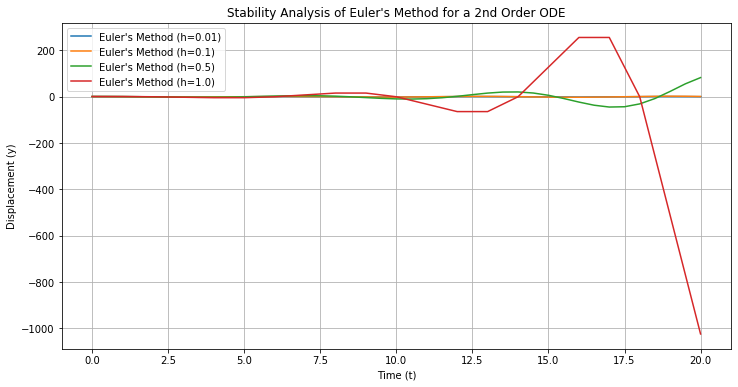

In [35]:
# Plot results for different step sizes
plt.figure(figsize=(12, 6))

for h in h_values:
    t, y = euler_method(h, k, t_start, t_end, y_0, v_0)
    plt.plot(t, y, label=f'Euler\'s Method (h={h})')
    stability_analysis(h, k)

plt.xlabel('Time (t)')
plt.ylabel('Displacement (y)')
plt.title('Stability Analysis of Euler\'s Method for a 2nd Order ODE')
plt.legend()
plt.grid(True)
plt.show()

The eigenvalues here are imaginary because the graph is oscillating. An oscillating equation can never be stable like this.